In [45]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import jensenshannon
import torch
import torch.nn as nn
import random
import seaborn as sns
import math
from matplotlib.widgets import Slider

from glm import get_X
from glm import get_y

In [16]:
datafile = '../kinpfn_testing_set/parquet_parsing/test_val_dataset.parquet' 

print('Getting features X from datafile '+datafile+' ...')
X, feature_names = get_X(datafile)
print('Done.\n')

print('Getting labels y from datafile '+datafile+' ...')
y, binedges_logfpt = get_y(datafile)
print('Done.\n')

Getting features X from datafile ../kinpfn_testing_set/parquet_parsing/test_val_dataset.parquet ...
Done.

Getting labels y from datafile ../kinpfn_testing_set/parquet_parsing/test_val_dataset.parquet ...
Done.



In [17]:
X_nontest, X_test, y_nontest, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

In [18]:
class GLM(nn.Module):
    def __init__(self, input_dim, n_bins=50):
        super().__init__()
        self.linear = nn.Linear(input_dim, n_bins)
    
    def forward(self, x):
        return self.linear(x)  # return logits; apply log_softmax in loss

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [19]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(kf.split(X_nontest)):
    print(f"Fold {fold+1}/5")
    print(len(train_idx))
    print(len(val_idx))

Fold 1/5
1804
451
Fold 2/5
1804
451
Fold 3/5
1804
451
Fold 4/5
1804
451
Fold 5/5
1804
451


In [103]:
# goal: train model with given learning_rate and weight_decay hyperparameters
# evaluate using k-fold cross-validation
# output the training loss and validation loss at the end of training

learning_rate = 1e-1
weight_decay = 1e-4

kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_train_losses = []
fold_val_losses = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_nontest)):
    print(f"Fold {fold+1}/5")

    # Split and scale
    X_train_fold, X_val_fold = X_nontest[train_idx], X_nontest[val_idx]
    y_train_fold, y_val_fold = y_nontest[train_idx], y_nontest[val_idx]

    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold)
    X_val_fold   = scaler.transform(X_val_fold)

    # Convert to tensors
    X_train_t = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_t = torch.tensor(y_train_fold, dtype=torch.float32)
    X_val_t   = torch.tensor(X_val_fold,   dtype=torch.float32)
    y_val_t   = torch.tensor(y_val_fold,   dtype=torch.float32)

    # Fresh model for each fold
    set_seed(42)
    model = GLM(input_dim=X_train_t.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    loss_fn = nn.KLDivLoss(reduction='batchmean')

    # Train
    for epoch in range(1000):
        model.train()
        log_probs = torch.log_softmax(model(X_train_t), dim=-1)
        loss = loss_fn(log_probs, y_train_t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Evaluate
    model.eval()
    with torch.no_grad():
        log_probs_train = torch.log_softmax(model(X_train_t), dim=-1)
        train_loss = loss_fn(log_probs_train, y_train_t).item()

        log_probs_val = torch.log_softmax(model(X_val_t), dim=-1)
        val_loss = loss_fn(log_probs_val, y_val_t).item()

    print(f"  Train KL divergence: {train_loss:.4f}")
    print(f"  Val KL divergence: {val_loss:.4f}")

    fold_train_losses.append(train_loss)
    fold_val_losses.append(val_loss)

print(f"\nMean train KL divergence: {np.mean(fold_train_losses):.4f} ± {np.std(fold_train_losses):.4f}")
print(f"\nMean val KL divergence: {np.mean(fold_val_losses):.4f} ± {np.std(fold_val_losses):.4f}")

Fold 1/5
  Train KL divergence: 0.4437
  Val KL divergence: 0.4695
Fold 2/5
  Train KL divergence: 0.4450
  Val KL divergence: 0.4587
Fold 3/5
  Train KL divergence: 0.4380
  Val KL divergence: 0.4925
Fold 4/5
  Train KL divergence: 0.4465
  Val KL divergence: 0.4526
Fold 5/5
  Train KL divergence: 0.4465
  Val KL divergence: 0.4463

Mean train KL divergence: 0.4439 ± 0.0031

Mean val KL divergence: 0.4639 ± 0.0162


In [102]:
# goal: train model with given learning_rate and weight_decay hyperparameters
# evaluate using k-fold cross-validation
# output the training loss and validation loss at the end of training

def perform_kfold_crossval(learning_rate, weight_decay, verbose=False):
    fold_train_losses = []
    fold_val_losses = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_nontest)):
        if verbose:
            print(f"Fold {fold+1}/5")

        # Split and scale
        X_train_fold, X_val_fold = X_nontest[train_idx], X_nontest[val_idx]
        y_train_fold, y_val_fold = y_nontest[train_idx], y_nontest[val_idx]

        scaler = StandardScaler()
        X_train_fold = scaler.fit_transform(X_train_fold)
        X_val_fold   = scaler.transform(X_val_fold)

        # Convert to tensors
        X_train_t = torch.tensor(X_train_fold, dtype=torch.float32)
        y_train_t = torch.tensor(y_train_fold, dtype=torch.float32)
        X_val_t   = torch.tensor(X_val_fold,   dtype=torch.float32)
        y_val_t   = torch.tensor(y_val_fold,   dtype=torch.float32)

        # Fresh model for each fold
        set_seed(42)
        model = GLM(input_dim=X_train_t.shape[1])
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        loss_fn = nn.KLDivLoss(reduction='batchmean')

        # Train
        for epoch in range(1000):
            model.train()
            log_probs = torch.log_softmax(model(X_train_t), dim=-1)
            loss = loss_fn(log_probs, y_train_t)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Evaluate
        model.eval()
        with torch.no_grad():
            log_probs_train = torch.log_softmax(model(X_train_t), dim=-1)
            train_loss = loss_fn(log_probs_train, y_train_t).item()

            log_probs_val = torch.log_softmax(model(X_val_t), dim=-1)
            val_loss = loss_fn(log_probs_val, y_val_t).item()

        if verbose:
            print(f"  Train KL divergence: {train_loss:.4f}")
            print(f"  Val KL divergence: {val_loss:.4f}")

        fold_train_losses.append(train_loss)
        fold_val_losses.append(val_loss)

    if verbose:
        print(f"\nMean train KL divergence: {np.mean(fold_train_losses):.4f} ± {np.std(fold_train_losses):.4f}")
        print(f"\nMean val KL divergence: {np.mean(fold_val_losses):.4f} ± {np.std(fold_val_losses):.4f}")
    
    return np.mean(fold_train_losses), np.mean(fold_val_losses), model.parameters

In [31]:
learning_rate = 1e-1
weight_decay = 1e-4

train_loss, val_loss, params = perform_kfold_crossval(learning_rate=learning_rate, weight_decay=weight_decay, verbose=False)
print(train_loss, val_loss)

0.44393917322158816 0.463908314704895


In [32]:
results = {}
for wd in np.logspace(-5, -1, 5):
  for lr in np.logspace(-5, -1, 5):
      train_loss, val_loss, params = perform_kfold_crossval(learning_rate=lr, weight_decay=wd, verbose=False)
      # Store results
      results[(wd, lr)] = (train_loss, val_loss, params)
      print(f'weight_decay {wd} lr {lr} train_loss {train_loss} val_loss {val_loss}')

weight_decay 1e-05 lr 1e-05 train_loss 1.4076202630996704 val_loss 1.4096665143966676
weight_decay 1e-05 lr 0.0001 train_loss 1.1244412422180177 val_loss 1.1350372314453125
weight_decay 1e-05 lr 0.001 train_loss 0.6199342846870423 val_loss 0.6380289435386658
weight_decay 1e-05 lr 0.01 train_loss 0.4464845597743988 val_loss 0.46864081025123594
weight_decay 1e-05 lr 0.1 train_loss 0.42533941864967345 val_loss 0.4467871367931366
weight_decay 0.0001 lr 1e-05 train_loss 1.4076212167739868 val_loss 1.4096641540527344
weight_decay 0.0001 lr 0.0001 train_loss 1.1244553327560425 val_loss 1.1350170612335204
weight_decay 0.0001 lr 0.001 train_loss 0.620587682723999 val_loss 0.6383256196975708
weight_decay 0.0001 lr 0.01 train_loss 0.4520757257938385 val_loss 0.47228533029556274
weight_decay 0.0001 lr 0.1 train_loss 0.44393917322158816 val_loss 0.463908314704895
weight_decay 0.001 lr 1e-05 train_loss 1.4076390743255616 val_loss 1.4096476316452027
weight_decay 0.001 lr 0.0001 train_loss 1.124684929

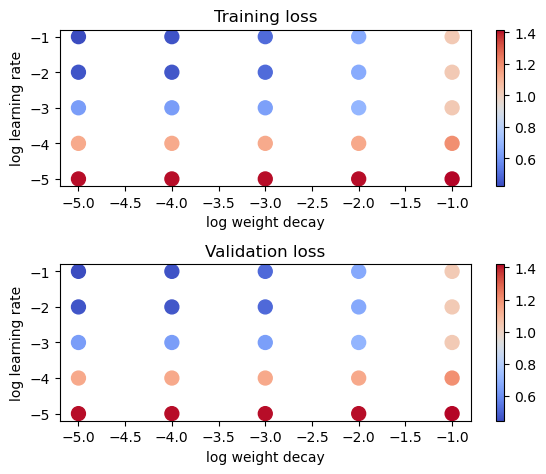

In [36]:
x_scatter = [math.log10(x[0]) for x in results]
y_scatter = [math.log10(x[1]) for x in results]

# plot training accuracy
marker_size = 100
colors = [results[x][0] for x in results]
plt.subplot(2, 1, 1)
plt.tight_layout(pad=3)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log weight decay')
plt.ylabel('log learning rate')
plt.title('Training loss')
 
plt.subplots_adjust(hspace=0.5)

# plot validation accuracy
colors = [results[x][1] for x in results] # default size of markers is 20
plt.subplot(2, 1, 2)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log weight decay')
plt.ylabel('log learning rate')
plt.title('Validation loss')

plt.savefig('lr_wd.pdf', bbox_inches='tight')
plt.savefig('lr_wd.png', bbox_inches='tight')

plt.show()

In [80]:
params_pytorch = results[(1e-1,1e-4)][2]
print(list(params_pytorch()))

[Parameter containing:
tensor([[ 0.0717,  0.0845,  0.0141,  ...,  0.0068, -0.0127,  0.0540],
        [-0.0766, -0.0227, -0.0060,  ..., -0.0182,  0.0380,  0.0072],
        [ 0.0280, -0.0450, -0.1139,  ..., -0.0431,  0.0972,  0.0058],
        ...,
        [ 0.0253,  0.0096, -0.1091,  ...,  0.0129, -0.0865,  0.0774],
        [ 0.0015,  0.0018, -0.0418,  ...,  0.0136,  0.1118,  0.0404],
        [ 0.0343,  0.0165,  0.0722,  ..., -0.0149,  0.0108, -0.0007]],
       requires_grad=True), Parameter containing:
tensor([-0.1596, -0.1383, -0.1449,  0.1069, -0.1460, -0.1605, -0.0055, -0.0943,
         0.0639,  0.0384,  0.0948, -0.0987,  0.0428,  0.0810, -0.0492,  0.0994,
         0.0712,  0.0500,  0.0734,  0.0147, -0.0857,  0.1229,  0.1350, -0.0416,
         0.1695, -0.0801,  0.2060,  0.2229,  0.1412, -0.0340,  0.1799,  0.1226,
         0.1385,  0.1419,  0.1723,  0.0004,  0.0382,  0.0704,  0.0198,  0.0786,
        -0.0572, -0.0723, -0.0454, -0.1208,  0.0465, -0.0647, -0.1604, -0.1047,
        -0.15

In [85]:
%matplotlib inline

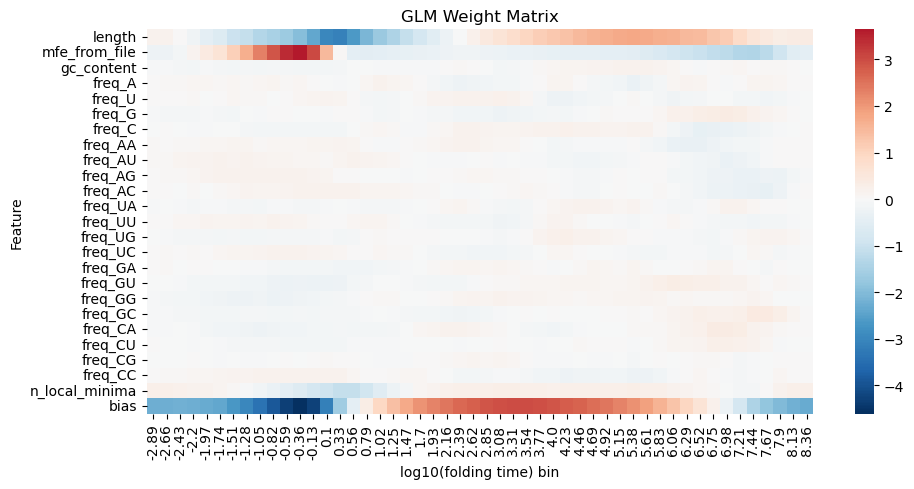

In [90]:
params_pytorch = results[(1e-4,1e-1)][2]

params = list(params_pytorch())
weights = params[0].detach().numpy()
biases = params[1].detach().numpy()
biases = biases.reshape((biases.shape[0], 1))
biases_weights = np.hstack((weights,biases))
weights_and_biases = np.hstack((weights,biases))

bin_centers = (binedges_logfpt[:-1] + binedges_logfpt[1:]) / 2

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(weights_and_biases.T, xticklabels=bin_centers.round(2), yticklabels=feature_names+['bias'],
           cmap='RdBu_r', center=0, ax=ax)
# sns.heatmap(weights.T, xticklabels=bin_centers.round(2),
#             cmap='RdBu_r', center=0, ax=ax)
ax.set_xlabel('log10(folding time) bin')
ax.set_ylabel('Feature')
plt.title('GLM Weight Matrix')
plt.tight_layout()

plt.savefig('weights_glm_wd1e-4_lr1e-1.pdf', bbox_inches='tight')
plt.savefig('weights_glm_wd1e-4_lr1e-1.png', bbox_inches='tight')

plt.show()

In [ ]:
%matplotlib tk

In [ ]:
params_pytorch = results[(1e-5,1e-1)][2]

params = list(params_pytorch())
weights = params[0].detach().numpy()
biases = params[1].detach().numpy()
biases = biases.reshape((biases.shape[0], 1))
biases_weights = np.hstack((weights,biases))
weights_and_biases = np.hstack((weights,biases))

bin_centers = (binedges_logfpt[:-1] + binedges_logfpt[1:]) / 2

fig = plt.figure(figsize=(10, 5))
ax = fig.add_axes([0.2, 0.3, 0.6, 0.6])
cbar_ax = fig.add_axes([0.85, 0.3, 0.02, 0.6])

sns.heatmap(weights_and_biases.T, xticklabels=bin_centers.round(2), yticklabels=feature_names+['bias'],
            cmap='RdBu_r', center=0, ax=ax, cbar_ax = cbar_ax)
plt.tight_layout()
plt.show()
ax.set_xlabel('log10(folding time) bin')
ax.set_ylabel('Feature')
ax.set_title('GLM Weight Matrix')

ax_lr = fig.add_axes([0.25, 0.1, 0.5, 0.03])
slider_lr = Slider(
    ax=ax_lr,
    label='learning_rate',
    valmin=-5,
    valmax=-1,
    valstep=1,
    valinit=-1
)

ax_wd = fig.add_axes([0.25, 0.05, 0.5, 0.03])
slider_wd = Slider(
    ax=ax_wd,
    label='weight_decay',
    valmin=-5,
    valmax=-1,
    valstep=1,
    valinit=-5
)


def update(val):
    lr = 10**slider_lr.val
    wd = 10**slider_wd.val

    params_pytorch = results[(wd,lr)][2]

    params = list(params_pytorch())
    weights = params[0].detach().numpy()
    biases = params[1].detach().numpy()
    biases = biases.reshape((biases.shape[0], 1))
    biases_weights = np.hstack((weights,biases))
    weights_and_biases = np.hstack((weights,biases))

    bin_centers = (binedges_logfpt[:-1] + binedges_logfpt[1:]) / 2

    ax.clear()
    cbar_ax.clear()
    sns.heatmap(weights_and_biases.T, xticklabels=bin_centers.round(2), yticklabels=feature_names+['bias'],
            cmap='RdBu_r', center=0, ax=ax, cbar_ax=cbar_ax)
    # sns.heatmap(weights.T, xticklabels=bin_centers.round(2),
    #             cmap='RdBu_r', center=0, ax=ax)

slider_lr.on_changed(update)
slider_wd.on_changed(update)

C:\Users\Julius\AppData\Local\Temp\ipykernel_28060\3010592020.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


0

In [64]:
%matplotlib tk

In [65]:
params_pytorch = results[(1e-5,1e-1)][2]

params = list(params_pytorch())
weights = params[0].detach().numpy()
biases = params[1].detach().numpy()
biases = biases.reshape((biases.shape[0], 1))
biases_weights = np.hstack((weights,biases))
weights_and_biases = np.hstack((weights,biases))

bin_centers = (binedges_logfpt[:-1] + binedges_logfpt[1:]) / 2

fig = plt.figure(figsize=(10, 5))
ax = fig.add_axes([0.2, 0.3, 0.6, 0.6])
cbar_ax = fig.add_axes([0.85, 0.3, 0.02, 0.6])

sns.heatmap(weights_and_biases.T, xticklabels=bin_centers.round(2), yticklabels=feature_names+['bias'],
            cmap='RdBu_r', center=0, ax=ax, cbar_ax = cbar_ax)
plt.tight_layout()
plt.show()
ax.set_xlabel('log10(folding time) bin')
ax.set_ylabel('Feature')
ax.set_title('GLM Weight Matrix')

ax_lr = fig.add_axes([0.25, 0.1, 0.5, 0.03])
slider_lr = Slider(
    ax=ax_lr,
    label='learning_rate',
    valmin=-5,
    valmax=-1,
    valstep=1,
    valinit=-1
)

ax_wd = fig.add_axes([0.25, 0.05, 0.5, 0.03])
slider_wd = Slider(
    ax=ax_wd,
    label='weight_decay',
    valmin=-5,
    valmax=-1,
    valstep=1,
    valinit=-5
)


def update(val):
    lr = 10**slider_lr.val
    wd = 10**slider_wd.val

    params_pytorch = results[(wd,lr)][2]

    params = list(params_pytorch())
    weights = params[0].detach().numpy()
    biases = params[1].detach().numpy()
    biases = biases.reshape((biases.shape[0], 1))
    biases_weights = np.hstack((weights,biases))
    weights_and_biases = np.hstack((weights,biases))

    bin_centers = (binedges_logfpt[:-1] + binedges_logfpt[1:]) / 2

    ax.clear()
    cbar_ax.clear()
    sns.heatmap(weights_and_biases.T, xticklabels=bin_centers.round(2), yticklabels=feature_names+['bias'],
            cmap='RdBu_r', center=0, ax=ax, cbar_ax=cbar_ax)
    # sns.heatmap(weights.T, xticklabels=bin_centers.round(2),
    #             cmap='RdBu_r', center=0, ax=ax)

slider_lr.on_changed(update)
slider_wd.on_changed(update)

C:\Users\Julius\AppData\Local\Temp\ipykernel_28060\3010592020.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


0

In [79]:
fig, ax = plt.subplots(5,5,  figsize = (10,5))
plt.subplots_adjust(hspace=0.5, wspace=0.2)

arr_wd = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
arr_lr = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]

for i in range(5):
    for j in range(5):
        wd = arr_wd[i]
        lr = arr_lr[j]

        params_pytorch = results[(wd,lr)][2]

        params = list(params_pytorch())
        weights = params[0].detach().numpy()
        biases = params[1].detach().numpy()
        biases = biases.reshape((biases.shape[0], 1))
        biases_weights = np.hstack((weights,biases))
        weights_and_biases = np.hstack((weights,biases))

        bin_centers = (binedges_logfpt[:-1] + binedges_logfpt[1:]) / 2

        # if i == 0 and j == 0:
        #     sns.heatmap(weights_and_biases.T, xticklabels=bin_centers.round(2), yticklabels=feature_names+['bias'],
        #                 cmap='RdBu_r', center=0, ax=ax[i][j])
        # else:
        #     sns.heatmap(weights_and_biases.T, xticklabels=False, yticklabels=False,
        #                 cmap='RdBu_r', center=0, ax=ax[i][j])

        sns.heatmap(weights_and_biases.T, xticklabels=False, yticklabels=False,
            cmap='RdBu_r', center=0, ax=ax[j][i])
        
        ax[j][i].tick_params(labelsize=6)
        ax[j][i].set_title(f'wd={wd:.1g}, lr={lr:.1g}', fontsize=8)

plt.savefig('glm_weights_function_of_lr_wd.pdf', bbox_inches='tight')
plt.savefig('glm_weights_function_of_lr_wd.png', bbox_inches='tight')

In [104]:
# example training curve

# goal: train model with given learning_rate and weight_decay hyperparameters
# evaluate using k-fold cross-validation
# output the training loss and validation loss at the end of training

learning_rate = 1e-1
weight_decay = 1e-4

kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_train_losses = []
fold_val_losses = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_nontest)):
    print(f"Fold {fold+1}/5")

    # Split and scale
    X_train_fold, X_val_fold = X_nontest[train_idx], X_nontest[val_idx]
    y_train_fold, y_val_fold = y_nontest[train_idx], y_nontest[val_idx]

    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold)
    X_val_fold   = scaler.transform(X_val_fold)

    # Convert to tensors
    X_train_t = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_t = torch.tensor(y_train_fold, dtype=torch.float32)
    X_val_t   = torch.tensor(X_val_fold,   dtype=torch.float32)
    y_val_t   = torch.tensor(y_val_fold,   dtype=torch.float32)

    # Fresh model for each fold
    set_seed(42)
    model = GLM(input_dim=X_train_t.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    loss_fn = nn.KLDivLoss(reduction='batchmean')

    # Train
    train_losses = []
    val_losses = []
    for epoch in range(1000):
        model.train()
        log_probs = torch.log_softmax(model(X_train_t), dim=-1)
        loss = loss_fn(log_probs, y_train_t)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            log_probs_val = torch.log_softmax(model(X_val_t), dim=-1)
            val_loss = loss_fn(log_probs_val, y_val_t)
        train_losses.append(loss.item())
        val_losses.append(val_loss.item())
    
    fold_train_losses.append(train_losses)
    fold_val_losses.append(val_losses)

    # Evaluate
    model.eval()
    with torch.no_grad():
        log_probs_train = torch.log_softmax(model(X_train_t), dim=-1)
        train_loss = loss_fn(log_probs_train, y_train_t).item()

        log_probs_val = torch.log_softmax(model(X_val_t), dim=-1)
        val_loss = loss_fn(log_probs_val, y_val_t).item()

    print(f"  Train KL divergence: {train_loss:.4f}")
    print(f"  Val KL divergence: {val_loss:.4f}")

# print(f"\nMean train KL divergence: {np.mean(fold_train_losses):.4f} ± {np.std(fold_train_losses):.4f}")
# print(f"\nMean val KL divergence: {np.mean(fold_val_losses):.4f} ± {np.std(fold_val_losses):.4f}")

Fold 1/5
  Train KL divergence: 0.4437
  Val KL divergence: 0.4695
Fold 2/5
  Train KL divergence: 0.4450
  Val KL divergence: 0.4587
Fold 3/5
  Train KL divergence: 0.4380
  Val KL divergence: 0.4925
Fold 4/5
  Train KL divergence: 0.4465
  Val KL divergence: 0.4526
Fold 5/5
  Train KL divergence: 0.4465
  Val KL divergence: 0.4463


In [105]:
fold_train_losses = np.array(fold_train_losses)
fold_val_losses = np.array(fold_val_losses)

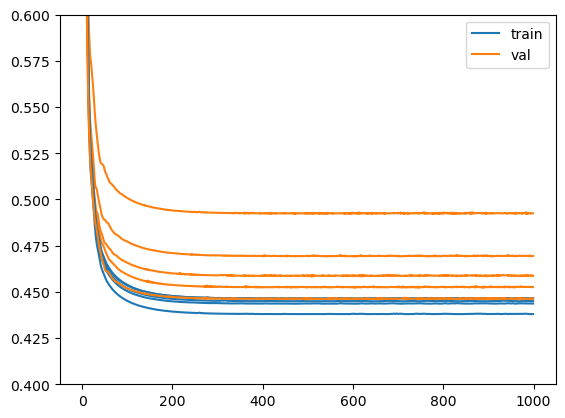

In [110]:
fig, ax = plt.subplots()

for fold in range(5):
    if fold == 0:
        ax.plot(fold_train_losses[fold], c='C0', label='train')
        ax.plot(fold_val_losses[fold], c='C1', label='val')
    else:
        ax.plot(fold_train_losses[fold], c='C0')
        ax.plot(fold_val_losses[fold], c='C1')
        
ax.set_ylim(0.4, 0.6)
ax.legend()

plt.savefig('training_curve_wd1e-4_lr1e-1.pdf', bbox_inches='tight')
plt.savefig('training_curve_wd1e-4_lr1e-1.png', bbox_inches='tight')